In [1]:
import requests
from IPython.core.display import HTML
# HTML(f"""
# <style>
# @import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
# </style>
# """)

# Non-linear decision boundary
The following exercise experiments with a dataset (see visualization in the cell below), where a linear model cannot seperate the different classes in the data.

<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#linear">Task 1: Non-linear decision boundary</a>
            </li>
            <li>
            <a href="#manual">Task 2: Circular boundary</a>
            </li>
            <li>
            <a href="#predict2">Task 3: Predictions for non-linear data</a>
            </li>
            <li>
            <a href="#predict53">Task 4: Predictions for non-linear data</a>
            </li>
            <li>
            <a href="#polar">Task 5: Polar coordinates</a>
            </li>
        </ul>
    </div>
</article>

Run the cell below to load libraries and functions and construct the dataset:


In [2]:
import numpy as np  # numeriacal computing
import matplotlib.pyplot as plt  # plotting core


def accuracy(predictions,targets):
    """
    :param predictions: 1D-array of predicted classes for the data.
    :param targets: 1D-array of actual classes for the data.
     
    :return: fraction of correctly predicted points (num_correct/num_points).
    """

    acc = np.sum(predictions == targets)/len(predictions)
    return acc

### Data generation
q1 = np.random.multivariate_normal([0, 0], [[.5, 0], [0, .5]], 400)

t = np.linspace(0, 2 * np.pi, 400)  ##  
q2 = np.array([(3 + q1[:, 0]) * np.sin(t), (3 + q1[:, 1]) * np.cos(t)]).T

The data of the two classes (`class 1`
 and `class 2`
) are stored in the variables `q1`
 and `q2`
, respectively. The following cell visualize the dataset of the two classes. `class 1`
 is labelled with 0s and `class 2`
 with 1s.


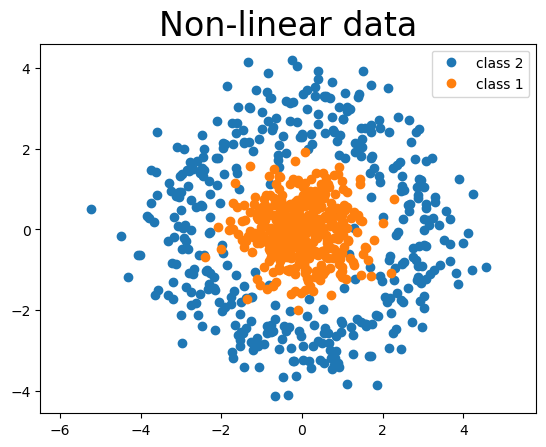

In [3]:
fig, ax = plt.subplots()
ax.plot(q2[:, 0], q2[:, 1], "o", label='class 2')
ax.plot(q1[:, 0], q1[:, 1], "o", label='class 1')

plt.title("Non-linear data", fontsize=24)
ax.axis('equal')
plt.legend()
plt.show()


---
**Task 1 (easy): Non-linear decision boundary👩‍💻💡**
The graph below shows how linear model performs on the current dataset (see last week
 ).
1. Using your observations about linear classification models, explain whether a linear classifier is an appropriate solution for the current data.
2. Which other models might provide a better fit to this dataset?


---

In [ ]:
# write your reflections here
# 1. Using your observations about linear classification models, explain whether a linear classifier is an appropriate solution for the current data.
# A linear classifier is not an appropriate solution for this dataset, as the two classes are not linearly separable. 
# The positive class is surrounded by the negative class in a circular pattern, which means that no straight line can effectively separate the two classes without misclassifying some points. 
# A linear decision boundary would fail to capture the true structure of the data, leading to poor classification performance.

# 2. Which other models might provide a better fit to this dataset?
# The two classes are arranged in a circular pattern, with one class surrounding the other. 
# A circular decision boundary would therefore be more suitable for separating the classes.
# Circles are functions on the form x^2 + y^2 = r^2, which is a quadratic equation. (Rearanged we get y = sqrt(r^2 - x^2), where r is the radius of the circle (a constant)).



Screenshot from webpage:

![linearModelOnNonLinearData.png](linearModelOnNonLinearData.png)


---
**Task 2 (easy): Circular boundary💡**
In this task the prediction function $f_w(x)$ is defined as a circular boundary centered in $[0,0]^T$.
1. Run the cell below to plot the circular boundary and the data points.
2. Change the radius of the decision boundary and determine which radius seems to best separate the classes?
3. Change the decision boundary and investigate how this affects the balance between false positives and false negatives? How does an overly large or small radius affect false positives and false negatives respectively? 


**Understanding the code**
The parametric equation of a circle, ([described in detail here](https://mathopenref.com/coordparamcircle.html)
) is given by:

$$
x = r \cos(t) \\
y = r \sin(t)
$$
where  $r$  is the radius of the circle and  $t$  represents angles (in radians) that range from  0  to  $2\pi$ .


---

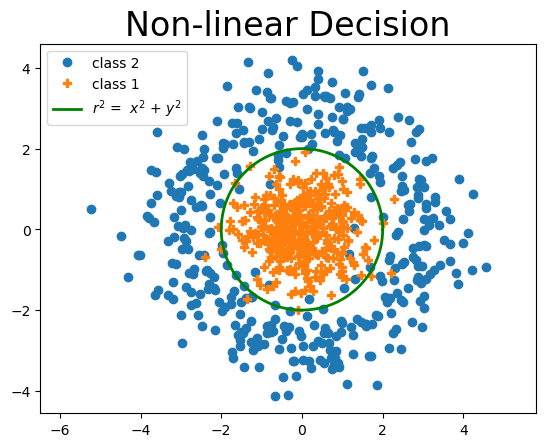

In [23]:
def circle_boundary(t, radius):
    """
    :param t: angle data points of the circle. 
    :param radius: radius of the circle
    :return: (x-values,y-values) of the circle points .
    """
    return (radius * np.cos(t), radius * np.sin(t))


fig, ax = plt.subplots()
ax.plot(q2[:, 0], q2[:, 1], "o", label='class 2')
ax.plot(q1[:, 0], q1[:, 1], "P", label='class 1')

t = np.linspace(0, 2 * np.pi, 400)  ### linspace of angles.
r = 2  # radius
x_c, y_c = circle_boundary(t, r)

ax.plot(x_c, y_c, "g",linewidth=2, label=r'$r^2$ =  $x^2$ + $y^2$')
plt.title("Non-linear Decision", fontsize=24)
ax.axis('equal')
plt.legend()
plt.show()


In [0]:
# write your reflections here
# 2. Change the radius of the decision boundary and determine which radius seems to best separate the classes?
# A radius of 2 seems to best separate the classes.

# 3. Change the decision boundary and investigate how this affects the balance between false positives and false negatives? 
# How does an overly large or small radius affect false positives and false negatives respectively? 
# Class 1 is the negative class (inside the circle) and class 2 is the positive class (outside the circle).
# A large radius increases false positives (class 1 points misclassified as class 2), 
# while a small radius increases false negatives (class 2 points misclassified as class 1).


---
**Task 3 (easy): Predictions for non-linear data👩‍💻**
This task is about using the circular decision boundary (parametrized by $r$)  to classify points. Since the points are centered in $[0,0]^T$ the classification function should just check whether the distance of the point to the center is smaller or greater than $r$. That is  $\sqrt{x^2 + y^2}≤r$, or equivalently,  $x^2 + y^2 ≤ r^2$.
The prediction function is given by $f_w(x)= x^2 + y^2 - r^2$ as the decision function must fulfill $f_w(x) = 0$ on the decision boundary
1. Comple the `predict_circle`
 function. The function should take radius and data ($(x, y)$ coordinates) as inputs and return an array of predicted classes based on the decision function, e.g.:    
   - -1 for points where  $x^2 + y^2 < r^2$  (inside the circle).
   - 1 for points where  $x^2 + y^2 > r^2$  (outside the circle).


2. Use the `accuracy`
 function to get the fraction of correctly predicted data points.


---

In [38]:
def predict_circle(radius, data):
    """
    :param radius: radius of the circular decision boundary.
    :param data: Array containing data points to classify.
    
    :return: Array of predictions (-1 for inside, 1 for outside the boundary).
    """
    # Write your implementation here
    distances_squared = data[:, 0]**2 + data[:, 1]**2
    predictions = np.where(distances_squared <= radius**2, -1, 1) # When distance=radius, we classify as inside the circle.
    return predictions


# Calculate accuracy here
r = 1.92  # radius
pred_1 = predict_circle(r, q1)
pred_2 = predict_circle(r, q2)
acc_1 = accuracy(pred_1, -np.ones(q1.shape[0]))
acc_2 = accuracy(pred_2, np.ones(q2.shape[0]))

print(f'A circular decision boundary with radius: {r:1}, has an accuracy of: {(acc_1+acc_2)/2:.3f}')

A circular decision boundary with radius: 1.92, has an accuracy of: 0.970



---
**Task 4 (easy): Predictions for non-linear data💡📽️**
In the cell below, reflect on:
1. Visually what is the optimal choice for radius of the classifier?
2. Try 10 different radius values and identify which one results in the highest accuracy.
3. How does the type of the data influence the choice of "optimality"? 


---

In [0]:
# write your reflections here
#1. Visually what is the optimal choice for radius of the classifier?
# I found that a radius of 2 visually appears to be the optimal choice for the circular classifier, but it can be hard to determine the exact optimal radius just by looking at the plot.

#2. Try 10 different radius values and identify which one results in the highest accuracy.
# The best one i found was radius = 1.92 which gave an accuracy of 0.970
# (radius 2 gave 0.963 accuracy)

#3. How does the type of the data influence the choice of "optimality"? 
# The optimal radius depends on the distribution and arrangement of the data points. 
# Different data patterns may require different radii to achieve the best classification performance.
# And different structures of data may require different types of decision boundaries altogether.
# The pattern/structure of the data highly depends on what scale the data is generated on and what axes the data is viewed from.


## Non-linear transformations to the data using polar coordinates
This task is about applying non-linear transformations to facilitate the use of a linear classifier. A point can be represented either by its Cartesian coordinates,  $x$, $y$ , or equivalently by its polar coordinates, defined by an angle $\theta$ and distance $r$ from the origin as shown in [Figure 1](#tensorboard). 
<div class="has-text-centered">
<figure class="image is-inline-block" id="tensorboard">

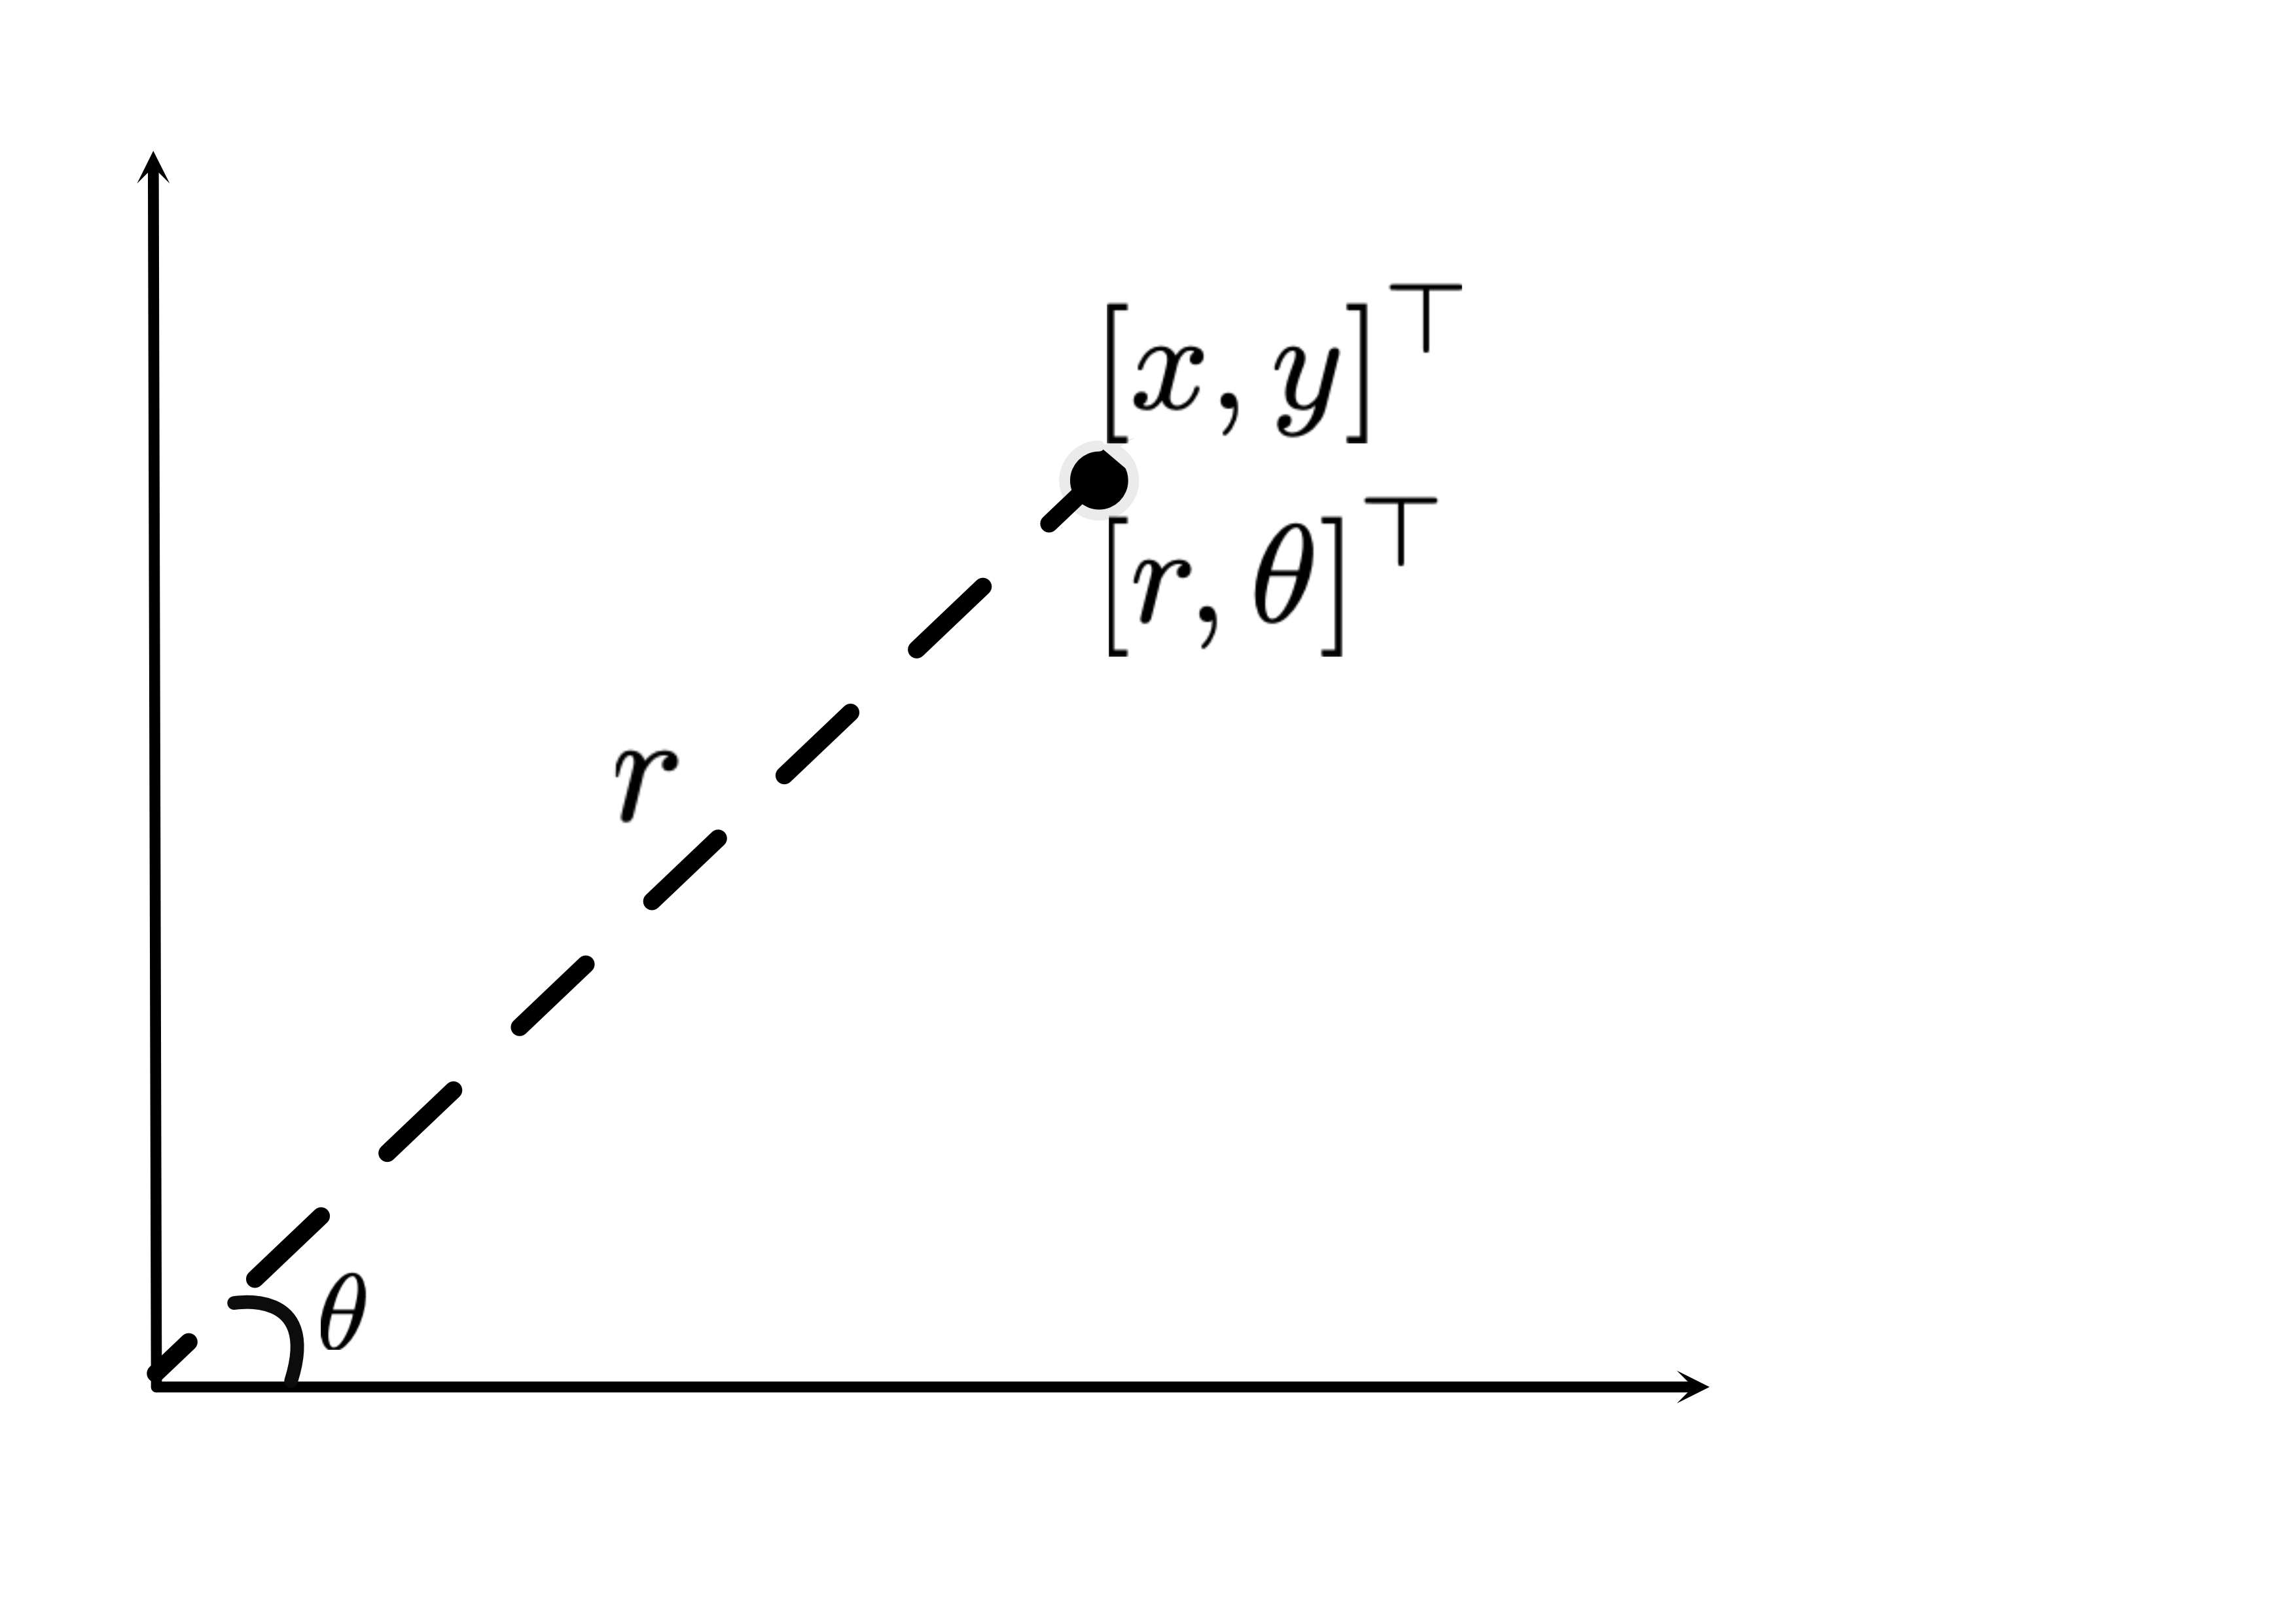

<figcaption class="figure-caption has-text-centered">Figure 1</figcaption>
</figure>
</div>

---
**Task 5 (easy): Polar coordinates👩‍💻💡📽️**
The function `map_to_polar_separable`
 below non-linearly transforms each point $(x, y)$ to its polar coordinates $(r, \theta)$.
1. Run the cell below to visualize the dataset in polar coordinates. 
2. Compare the distribution of the data in polar versus Cartesian coordinates. What key differences do you observe?
3. Does transforming the data to polar coordinates make it easier to separate the classes with a linear classifier? How does this transformation change the classification problem?
4. Which parameter separates the classes?
5. Reflect on how pre-processing of data can change the models used for classification.
6. How is the non-linear transformation to polar coordinates different from using kernels for classification?


---

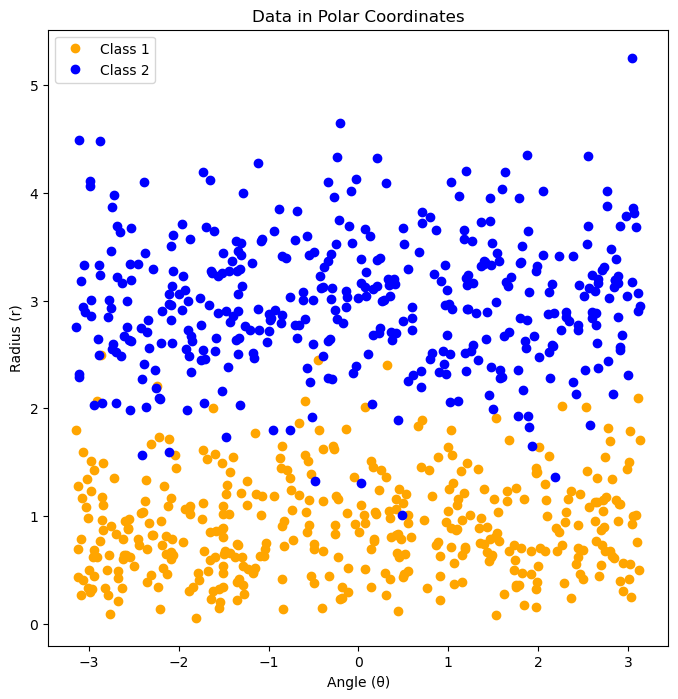

In [40]:
def map_to_polar_separable(data):
    """
    Maps circular data centered at (0, 0) to polar coordinates (r, theta),
    making the data linearly separable by radius (r).
 
    Parameters:
    - data: A numpy array of shape (N, 2) where each row is a point (x, y).
 
    Returns:
    - polar_data: A numpy array of shape (N, 2) where each row is (r, theta),
      where r is the radial distance and theta is the angle in radians.
    """
    # Convert to polar coordinates
    r = np.sqrt(data[:, 0]**2 + data[:, 1]**2)  # Radial distance
    theta = np.arctan2(data[:, 1], data[:, 0])  # Angle in radians
   
    # Stack r and theta to form polar data
    polar_data = np.column_stack((r, theta))
   
    return polar_data
   
data = np.vstack([q1, q2])  
polar_data=map_to_polar_separable(data)

# Split polar data into classes
polar_q1 = polar_data[:len(q1)]
polar_q2 = polar_data[len(q1):]

# Plot data in polar coordinates
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(polar_q1[:, 1], polar_q1[:, 0], "o", label="Class 1", color="orange")
ax.plot(polar_q2[:, 1], polar_q2[:, 0], "o", label="Class 2", color="blue")
plt.xlabel("Angle (θ)")
plt.ylabel("Radius (r)")
plt.title("Data in Polar Coordinates")
plt.legend()
plt.show()

In [0]:
# Write reflections here

#The function `map_to_polar_separable` non-linearly transforms each point $(x, y)$ to its polar coordinates $(r, \theta)$.
# 1. Run the cell below to visualize the dataset in polar coordinates. 

# 2. Compare the distribution of the data in polar versus Cartesian coordinates. What key differences do you observe?
# In Cartesian coordinates, the data points are arranged in a circular pattern, with class 1 points clustered near the origin and class 2 points forming a ring around them.
# In polar coordinates, the radial distance (r) effectively separates the two classes, with class 1 points having smaller r values and class 2 points having larger r values.

# 3. Does transforming the data to polar coordinates make it easier to separate the classes with a linear classifier? How does this transformation change the classification problem?
# In Cartesian coordinates, the classes are not linearly separable due to their circular arrangement, where one class surrounds the other. We needed a non-linear decision boundary (circle) to separate them.
# In polar coordinates, the two classes become linearly separable along the radius (r) axis, as class 1 points have smaller r values and class 2 points have larger r values.
# A simple linear decision boundary based on r can effectively separate the classes.

# 4. Which parameter separates the classes?
# The radial distance (r) separates the classes.
# The angle (theta) does not contribute to the separation of the classes in this case, since the angle varies uniformly for both classes.

# 5. Reflect on how pre-processing of data can change the models used for classification.
# Pre-processing data through transformations like converting to polar coordinates can significantly alter the structure of the data, making it easier to classify with simpler models.
# By transforming the data into a space where the classes are linearly separable, we can use linear classifiers instead of more complex non-linear models, which can improve interpretability and reduce computational complexity

# 6. How is the non-linear transformation to polar coordinates different from using kernels for classification?
# Using kernels for classification means implicitly mapping data to a higher-dimensional space to make it linearly separable, without explicitly transforming the data points. Features usually have no simple physical meaning.
# The non-linear transformation to polar coordinates is an explicit transformation that changes the representation of the data points themselves, based on known geometric properties.
# Kernels allow us to work in the original space while benefiting from the properties of a higher-dimensional space, whereas explicit transformations change the data representation directly.
# But both approaches aim to achieve linear separability of classes that are not linearly separable in the original space.
# You could say that the polar transformation is a specific type of feature mapping, similar in spirit to kernel methods, but applied explicitly rather than implicitly.

# Polar coordinates: “I know the structure of the problem, so I’ll reshape the space in a specific way.”
# Kernels: “I don’t know the right features, so I’ll let a very rich feature space handle it implicitly.”
# In short, polar coordinate transformation is a specific, explicit non-linear feature mapping, 
# while kernel methods are a general, implicit framework for learning non-linear decision boundaries without explicitly defining the features.